# Implementing Techniques for Detecting and Mitigating Bias in Generative Models

## 📚 Learning Objectives

By completing this notebook, you will:
- Detect bias in generative models
- Measure bias metrics
- Implement bias mitigation techniques
- Evaluate mitigation effectiveness
- Apply fairness principles

## 🔗 Where this fits

**Builds on:** Course 06 (AIAT 116) — Unit 2 (bias detection and mitigation) and Course 07 (AIAT 121) — Unit 5, which audited a language model; here the audited model is generative.

**Used later in:** Course 10 — Unit 4, lesson 04, which turns fairness duties into compliance checks.

---

This notebook covers practical activities from **Course 10, Unit 4**:
- Implementing techniques for detecting and mitigating bias in generative models

---

## Introduction

**Bias detection and mitigation** in generative models ensures fair and equitable outputs across different demographic groups and use cases.

We do it in two hands-on parts:

1. **Warm-up (classifier):** audit a predictive model for group disparity — the standard fairness workflow
2. **Main event (generative):** train a tiny text *generator* on a biased corpus, **measure** the stereotypes in what it generates, **mitigate** them by balancing the training data, and **verify** the fix

---

## 🌍 Why this lesson exists — amplified, not merely reflected

Bianchi et al. (FAccT 2023, arXiv 2211.03759), *Easily Accessible Text-to-Image Generation Amplifies Demographic Stereotypes at Large Scale*, tested ordinary prompts against widely-deployed text-to-image systems and found "a broad range of ordinary prompts produce stereotypes" of race, gender and cultural norms — and, crucially, that "stereotypes persist despite mitigation strategies". The outputs were more skewed than the real-world statistics they were supposedly reflecting. The model amplified.

That is the failure this notebook measures and then fixes at toy scale. Its mirror image — Google pausing Gemini's people-generation in February 2024 after over-correction produced racially diverse 1943 German soldiers — is what happens when a team mitigates without measuring. Under-correct and you amplify; over-correct and you fabricate. Only a metric tells you which side you are on.

**What goes wrong without this:** a classifier's bias produces an unfair decision that a person can appeal. A generator's bias produces *content* — endless images of "a doctor", all men — with no decision, no appellant, and no moment anyone can point to. It is therefore measured far less often and shipped far more often.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# WHAT/WHY: roadmap cell — the detection metrics and mitigation techniques
# this notebook then demonstrates with a concrete loan-approval audit.
import numpy as np
import pandas as pd

print("✅ Libraries imported!")
print("\nDetecting and Mitigating Bias in Generative Models")
print("=" * 60)

print("\nBias Detection:")
print("  - Representation bias")
print("  - Stereotyping")
print("  - Demographic parity")
print("  - Equalized odds")


# Once bias is measured, these are the levers for reducing it.
print("\nMitigation Techniques:")
print("  - Data balancing")
print("  - Fairness constraints")
print("  - Adversarial debiasing")
print("  - Post-processing")

print("\nEvaluation:")
print("  - Bias metrics")
print("  - Fairness audits")
print("  - Impact assessment")
print("  - Continuous monitoring")

print("\n✅ Bias mitigation concepts understood!")

✅ Libraries imported!

Detecting and Mitigating Bias in Generative Models

Bias Detection:
  - Representation bias
  - Stereotyping
  - Demographic parity
  - Equalized odds

Mitigation Techniques:
  - Data balancing
  - Fairness constraints
  - Adversarial debiasing
  - Post-processing

Evaluation:
  - Bias metrics
  - Fairness audits
  - Impact assessment
  - Continuous monitoring

✅ Bias mitigation concepts understood!


## Part 1 (Warm-up) — Detecting Gender Bias in a Classifier

**Industry context — three real, sourced incidents:**
- Amazon scrapped an experimental hiring model in 2018 after it penalised resumes mentioning "women's" activities (Reuters, 2018)
- A widely used US healthcare risk model gave Black patients lower risk scores than equally sick white patients (Obermeyer et al., *Science* 366, 2019)
- With identical targeting settings, Facebook delivered a truck-driver job ad to 4,864 men and 386 women, and a childcare ad to 6,456 women and 258 men (AlgorithmWatch, 2020)

We **measure and visualise** demographic bias in a classifier first, because the metrics are easier to read there — then Part 2 moves the same question to a *generative* model, where there is no decision to appeal.

titanic: full file, 891 rows.
Loaded 891 real passenger records
Real missing values — Age: 177, Cabin: 687, Embarked: 2

Real outcome in the historical record:
  women survived: 74.2%   men survived: 18.9%
  disparity in the ground truth itself: 55.3%

model                    accuracy  female +rate  male +rate     gap
aware (uses Sex)            79.9%         90.7%        8.8%   81.9%
blind (Sex dropped)         70.1%         35.1%       21.6%   13.4%

Proxy check: Sex predicted from the 'blind' features alone = 66.0% (majority-class baseline 63.8%)


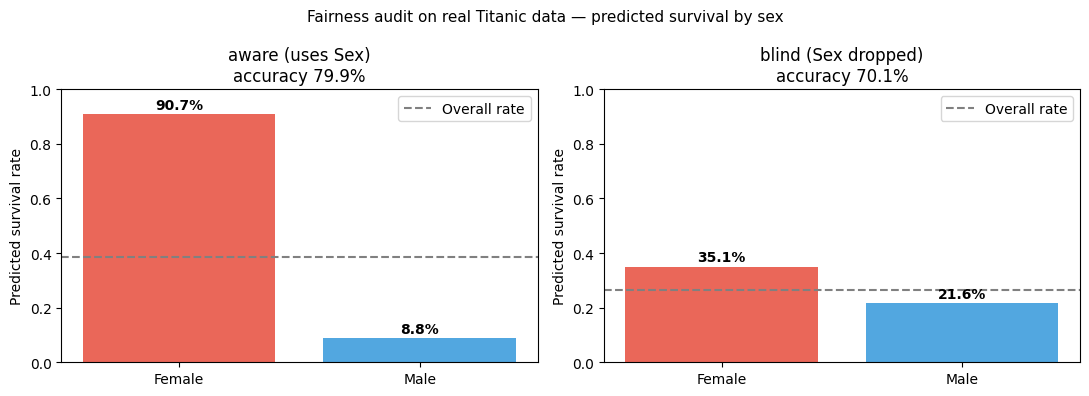


What the audit actually found:
  1. Dropping Sex cut the predicted-rate gap from 81.9% to 13.4% —
     but it did NOT reach zero, and accuracy fell 79.9% → 70.1% (9.7% lost).
  2. Equal opportunity (true-positive rate among passengers who DID survive):
     aware  — women 97.1% vs men 24.2%
     blind  — women 44.3% vs men 48.5%
  3. The real disparity is untouched. 74.2% of women and 18.9% of men actually survived;
     hiding the column changes the model, not the world it learns from.

'Fairness through unawareness' is a weak guarantee: it costs accuracy, it
leaves a residual gap, and where proxy features are strong it does not even
hide the attribute. Real audits use Fairlearn (Microsoft) or IBM AI Fairness
360 and report several metrics, because no single number settles fairness.


In [2]:
# WHAT/WHY: a hands-on fairness audit on REAL data — the Titanic passenger
# manifest, a historical decision process with a documented demographic
# disparity. We train the model WITH and WITHOUT the protected attribute
# (Sex) and measure what "fairness through unawareness" actually buys.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ── REAL DATA: 891 passengers of the RMS Titanic ──────────────────────────
# The whole 891-row file ships with the repository, so load() gives every
# machine the same 891 rows and the numbers below are identical everywhere.
# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/...' only resolves when the kernel's
#       working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve("https://raw.githubusercontent.com/A-Alwabel/AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load
# -------------------------------------------------------------------------------------
df = load("titanic")
print(f'Loaded {len(df)} real passenger records')
print(f'Real missing values — Age: {df["Age"].isna().sum()}, '
      f'Cabin: {df["Cabin"].isna().sum()}, Embarked: {df["Embarked"].isna().sum()}')

d = df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']].copy()
# Real missingness has to be handled before modelling; median imputation is the
# simplest defensible choice and we state it rather than hiding it.
d['Age'] = d['Age'].fillna(d['Age'].median())
d['male'] = (d['Sex'] == 'male').astype(int)

# ── The disparity is IN THE DATA, before any model exists ─────────────────
rate_by_sex = d.groupby('Sex')['Survived'].mean()
print(f"\nReal outcome in the historical record:")
print(f"  women survived: {rate_by_sex['female']:.1%}   men survived: {rate_by_sex['male']:.1%}")
print(f"  disparity in the ground truth itself: "
      f"{abs(rate_by_sex['female'] - rate_by_sex['male']):.1%}")

FEAT_AWARE = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'male']   # includes Sex
FEAT_BLIND = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']           # Sex removed
tr, te = train_test_split(d, test_size=0.3, random_state=42, stratify=d['Survived'])
male_te = te['male'].to_numpy() == 1
y_te = te['Survived'].to_numpy()

# ── Train two models: sex-aware and sex-blind ─────────────────────────────
results = {}
print(f"\n{'model':<24}{'accuracy':>9}{'female +rate':>14}{'male +rate':>12}{'gap':>8}")
for name, feats in [('aware (uses Sex)', FEAT_AWARE), ('blind (Sex dropped)', FEAT_BLIND)]:
    m = LogisticRegression(max_iter=2000).fit(tr[feats], tr['Survived'])
    pred = m.predict(te[feats])
    rate_f, rate_m = pred[~male_te].mean(), pred[male_te].mean()
    acc = accuracy_score(y_te, pred)
    results[name] = dict(pred=pred, acc=acc, rate_f=rate_f, rate_m=rate_m,
                         gap=abs(rate_m - rate_f),
                         tpr_f=pred[(~male_te) & (y_te == 1)].mean(),
                         tpr_m=pred[(male_te) & (y_te == 1)].mean())
    print(f"{name:<24}{acc:9.1%}{rate_f:14.1%}{rate_m:12.1%}{abs(rate_m-rate_f):8.1%}")

# ── Does dropping Sex actually hide it? Test for PROXIES ──────────────────
# If the remaining features predict Sex better than always guessing the
# majority, a model can rediscover it - "unawareness" is not erasure.
proxy = LogisticRegression(max_iter=2000).fit(tr[FEAT_BLIND], tr['male'])
proxy_acc = proxy.score(te[FEAT_BLIND], te['male'])
majority = max(te['male'].mean(), 1 - te['male'].mean())
print(f"\nProxy check: Sex predicted from the 'blind' features alone = {proxy_acc:.1%} "
      f"(majority-class baseline {majority:.1%})")

# ── Visualise ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, name in zip(axes, results):
    r = results[name]
    bars = ax.bar(['Female', 'Male'], [r['rate_f'], r['rate_m']],
                  color=['#e74c3c', '#3498db'], alpha=0.85)
    ax.set_ylim(0, 1)
    ax.set_title(f"{name}\naccuracy {r['acc']:.1%}")
    ax.axhline(r['pred'].mean(), color='gray', linestyle='--', label='Overall rate')
    ax.legend(); ax.set_ylabel('Predicted survival rate')
    for bar, rate in zip(bars, [r['rate_f'], r['rate_m']]):
        ax.text(bar.get_x() + bar.get_width()/2, rate + 0.02, f"{rate:.1%}",
                ha='center', fontweight='bold')
plt.suptitle('Fairness audit on real Titanic data — predicted survival by sex', fontsize=11)
plt.tight_layout(); plt.show()

# ── Read the numbers, not the wish ────────────────────────────────────────
a, b = results['aware (uses Sex)'], results['blind (Sex dropped)']
print(f"\nWhat the audit actually found:")
print(f"  1. Dropping Sex cut the predicted-rate gap from {a['gap']:.1%} to {b['gap']:.1%} —")
print(f"     but it did NOT reach zero, and accuracy fell "
      f"{a['acc']:.1%} → {b['acc']:.1%} ({a['acc']-b['acc']:.1%} lost).")
print(f"  2. Equal opportunity (true-positive rate among passengers who DID survive):")
print(f"     aware  — women {a['tpr_f']:.1%} vs men {a['tpr_m']:.1%}")
print(f"     blind  — women {b['tpr_f']:.1%} vs men {b['tpr_m']:.1%}")
print(f"  3. The real disparity is untouched. {rate_by_sex['female']:.1%} of women and "
      f"{rate_by_sex['male']:.1%} of men actually survived;")
print(f"     hiding the column changes the model, not the world it learns from.")
print("\n'Fairness through unawareness' is a weak guarantee: it costs accuracy, it")
print("leaves a residual gap, and where proxy features are strong it does not even")
print("hide the attribute. Real audits use Fairlearn (Microsoft) or IBM AI Fairness")
print("360 and report several metrics, because no single number settles fairness.")


## Part 2 — Detecting and Mitigating Bias in a *Generative* Model

Generative models have a different failure mode than classifiers: instead of unfair *decisions*,
they produce **biased content** — e.g., language models associating occupations with genders.

Below we make this concrete at toy scale with a **bigram-style text generator** (the same
conditional-probability mechanism inside every language model, just tiny):

1. **Train** it on a corpus of occupation sentences with a realistic stereotype skew
2. **Detect:** generate 2,000 sentences and measure the pronoun distribution per occupation
3. **Mitigate:** apply **counterfactual data augmentation** — add gender-swapped copies of the
   training sentences so each occupation appears equally with "he" and "she" — and retrain
4. **Verify:** re-generate and re-measure — the metric, not our intentions, tells us if it worked

This is the same audit loop used on real systems (e.g., the WinoBias benchmark for coreference
bias, and demographic audits of image generators) — only the model size differs.

In [3]:
# Generative-bias demo: train a tiny text generator on a biased corpus, measure the
# bias in its OUTPUTS, mitigate by balancing the training data, and re-measure.
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(0)

# ── 1. Biased training corpus ──────────────────────────────────────────────
# Sentence template: "the <occupation> said <pronoun> is busy".
# Counts mimic a real-world stereotype skew in text data (e.g., news corpora).
biased_counts = {                     # occupation: (# sentences with "he", # with "she")
    'doctor':   (18, 2),
    'engineer': (17, 3),
    'nurse':    (2, 18),
    'teacher':  (5, 15),
}
def build_corpus(counts):
    """Expand the count table into an actual list of training sentences."""
    corpus = []
    for occ, (n_he, n_she) in counts.items():
        corpus += [f"the {occ} said he is busy"] * n_he
        corpus += [f"the {occ} said she is busy"] * n_she
    return corpus

# ── 2. "Train" a minimal generative language model ────────────────────────
# A bigram-style model = conditional probability tables estimated from the corpus.
# Here the model learns P(pronoun | occupation) — the exact statistic an LSTM/transformer
# would also absorb from this data, just without the neural machinery around it.
def train_generator(corpus):
    counts = {}
    for sent in corpus:
        occ, pron = sent.split()[1], sent.split()[3]   # parse "the OCC said PRON ..."
        counts.setdefault(occ, {'he': 0, 'she': 0})
        counts[occ][pron] += 1
    # Normalize counts into sampling probabilities
    return {occ: {p: c / sum(d.values()) for p, c in d.items()} for occ, d in counts.items()}

def generate(model, n):
    """Sample n sentences: occupation uniform, pronoun from the learned conditional."""
    occs = list(model)
    out = []
    for _ in range(n):
        occ = occs[rng.integers(len(occs))]
        pron = 'he' if rng.random() < model[occ]['he'] else 'she'
        out.append(f"the {occ} said {pron} is busy")
    return out

# ── 3. DETECT: measure pronoun share per occupation in generated text ─────
def he_share(sentences):
    """For each occupation, fraction of generated sentences that used 'he'."""
    tally = {}
    for s in sentences:
        occ, pron = s.split()[1], s.split()[3]
        tally.setdefault(occ, []).append(pron == 'he')
    return {occ: float(np.mean(v)) for occ, v in tally.items()}

model_biased = train_generator(build_corpus(biased_counts))
sample_biased = generate(model_biased, 2000)
share_biased = he_share(sample_biased)

print("Sample generations (biased model):")
for s in sample_biased[:3]:
    print("  ", s)

# Bias metric: average absolute deviation from 50/50 pronoun balance
bias_metric = lambda share: float(np.mean([abs(v - 0.5) for v in share.values()]))
print("\n'he' share per occupation (BIASED model, 2000 samples):")
for occ, v in sorted(share_biased.items()):
    print(f"  {occ:9s}: {v:.1%}")
print(f"Bias score (mean |he-share − 50%|): {bias_metric(share_biased):.1%}")

Sample generations (biased model):
   the teacher said she is busy
   the nurse said he is busy
   the doctor said he is busy

'he' share per occupation (BIASED model, 2000 samples):
  doctor   : 91.2%
  engineer : 87.0%
  nurse    : 7.8%
  teacher  : 25.7%
Bias score (mean |he-share − 50%|): 36.2%


'he' share per occupation (MITIGATED model, 2000 samples):
  doctor   : 49.0%
  engineer : 49.8%
  nurse    : 52.3%
  teacher  : 48.8%

Bias score before mitigation: 36.2%
Bias score after  mitigation: 1.2%


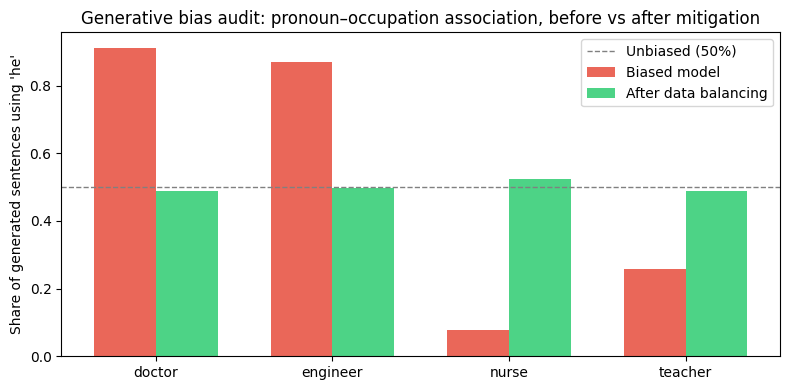

In [4]:
# ── 4. MITIGATE: counterfactual data augmentation, then VERIFY ────────────
# Mitigation = for every training sentence, also add its gender-swapped copy.
# After augmentation each occupation appears equally often with "he" and "she",
# so the generator can no longer learn the stereotype from the data.
swap = {'he': 'she', 'she': 'he'}
augmented = build_corpus(biased_counts)
augmented += [' '.join(swap.get(w, w) for w in s.split()) for s in augmented]

model_fair = train_generator(augmented)
sample_fair = generate(model_fair, 2000)
share_fair = he_share(sample_fair)

print("'he' share per occupation (MITIGATED model, 2000 samples):")
for occ, v in sorted(share_fair.items()):
    print(f"  {occ:9s}: {v:.1%}")

# Verify with the same metric we used for detection — the numbers decide, not us
b_before, b_after = bias_metric(share_biased), bias_metric(share_fair)
print(f"\nBias score before mitigation: {b_before:.1%}")
print(f"Bias score after  mitigation: {b_after:.1%}")

# ── Visualize before vs after ─────────────────────────────────────────────
occs = sorted(share_biased)
x = np.arange(len(occs)); w = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w/2, [share_biased[o] for o in occs], w, label='Biased model', color='#e74c3c', alpha=0.85)
ax.bar(x + w/2, [share_fair[o] for o in occs], w, label='After data balancing', color='#2ecc71', alpha=0.85)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Unbiased (50%)')
ax.set_xticks(x); ax.set_xticklabels(occs)
ax.set_ylabel("Share of generated sentences using 'he'")
ax.set_title("Generative bias audit: pronoun–occupation association, before vs after mitigation")
ax.legend(); plt.tight_layout(); plt.show()

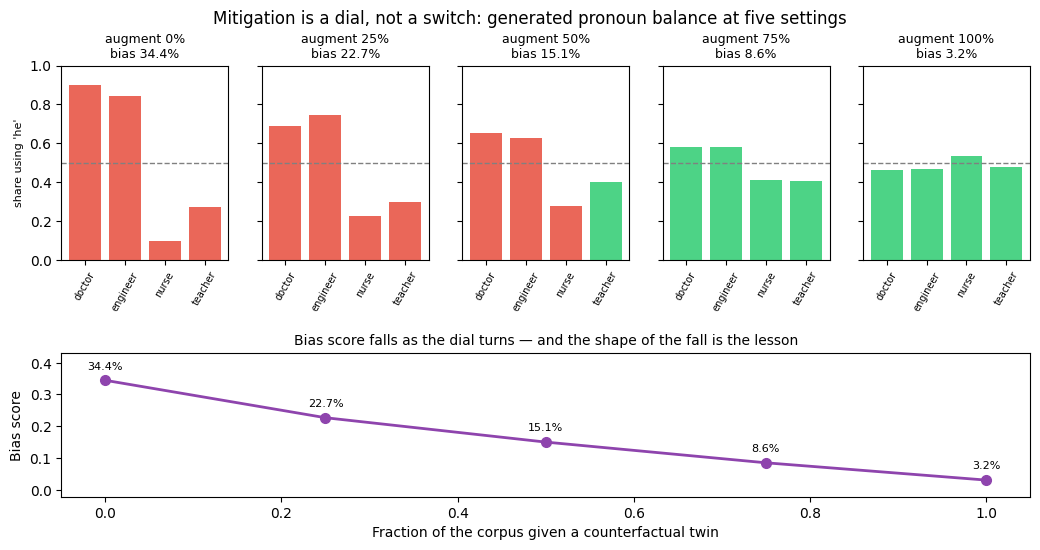

 augment  corpus    doctor  engineer     nurse   teacher    bias
----------------------------------------------------------------
      0%      80    89.9%     84.5%      9.5%     27.2%   34.4%
     25%     100    68.7%     74.6%     22.8%     29.6%   22.7%
     50%     120    65.3%     62.9%     27.8%     40.0%   15.1%
     75%     140    58.1%     57.9%     40.9%     40.5%    8.6%
    100%     160    46.4%     46.6%     53.6%     47.9%    3.2%

First half of the dial (0% -> 50%) removed 19.3% of bias; the second half (50% -> 100%) removed 11.9%.
Each row is a re-measurement, not a prediction: the model was retrained and 2,000 fresh
sentences were generated at every setting.


In [5]:
# WHAT/WHY: the cell above gave you two dots - fully biased, and fully balanced. Real mitigation
# is never that switch. You augment SOME fraction of the corpus, ship, and re-measure. Here we
# turn that dial from 0% to 100% and watch what the generator's outputs do at each setting:
# a storyboard of five snapshots, the curve they trace, and the step table behind both.
alphas = [0.0, 0.25, 0.5, 0.75, 1.0]        # fraction of training sentences given a swapped twin


def augment(counts, alpha):
    """Corpus where a random fraction `alpha` of the sentences also gets a gender-swapped twin.
    alpha=0 is the untouched biased corpus; alpha=1 is the full counterfactual augmentation
    used in the cell above."""
    corpus = build_corpus(counts)
    n_swap = int(round(alpha * len(corpus)))
    picked = rng.permutation(len(corpus))[:n_swap]
    return corpus + [' '.join(swap.get(w, w) for w in corpus[i].split()) for i in picked]


# ── Run the sweep: retrain and RE-MEASURE at every setting of the dial ─────────────────────
steps = []
for a in alphas:
    corpus_a = augment(biased_counts, a)
    share_a = he_share(generate(train_generator(corpus_a), 2000))
    steps.append({'alpha': a, 'n': len(corpus_a), 'share': share_a,
                  'score': bias_metric(share_a)})

occs = sorted(share_biased)

# ── The storyboard: one frame per setting, plus the curve they trace ───────────────────────
fig = plt.figure(figsize=(12.5, 5.6))
gs = fig.add_gridspec(2, len(alphas), height_ratios=[1.35, 1], hspace=0.55)
for k, st in enumerate(steps):
    ax = fig.add_subplot(gs[0, k])
    ax.bar(range(len(occs)), [st['share'][o] for o in occs],
           color=['#e74c3c' if abs(st['share'][o] - 0.5) > 0.1 else '#2ecc71' for o in occs],
           alpha=0.85)
    ax.axhline(0.5, color='gray', ls='--', lw=1)
    ax.set_ylim(0, 1); ax.set_xticks(range(len(occs)))
    ax.set_xticklabels(occs, rotation=60, fontsize=7)
    ax.set_title(f"augment {st['alpha']:.0%}\nbias {st['score']:.1%}", fontsize=9)
    if k == 0:
        ax.set_ylabel("share using 'he'", fontsize=8)
    else:
        ax.set_yticklabels([])

axc = fig.add_subplot(gs[1, :])
axc.plot([s['alpha'] for s in steps], [s['score'] for s in steps], 'o-',
         color='#8e44ad', lw=2, ms=7)
for s in steps:
    axc.annotate(f"{s['score']:.1%}", (s['alpha'], s['score']),
                 textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)
axc.set_xlabel('Fraction of the corpus given a counterfactual twin')
axc.set_ylabel('Bias score')
axc.set_ylim(-0.02, max(s['score'] for s in steps) * 1.25)
axc.set_title('Bias score falls as the dial turns — and the shape of the fall is the lesson',
              fontsize=10)
fig.suptitle('Mitigation is a dial, not a switch: generated pronoun balance at five settings',
             fontsize=12)
plt.show()

# ── The step table: every number the storyboard is drawn from ──────────────────────────────
header = f"{'augment':>8}{'corpus':>8}" + ''.join(f"{o:>10}" for o in occs) + f"{'bias':>8}"
print(header); print('-' * len(header))
for s in steps:
    print(f"{s['alpha']:8.0%}{s['n']:8d}"
          + ''.join(f"{s['share'][o]:9.1%} " for o in occs)
          + f"{s['score']:7.1%}")
first_half = steps[0]['score'] - steps[2]['score']
second_half = steps[2]['score'] - steps[-1]['score']
print(f"\nFirst half of the dial (0% -> 50%) removed {first_half:.1%} of bias; "
      f"the second half (50% -> 100%) removed {second_half:.1%}.")
print("Each row is a re-measurement, not a prediction: the model was retrained and 2,000 fresh")
print("sentences were generated at every setting.")


### 🔎 Read the storyboard

**Top row — five snapshots of one audit.** Every frame is the *same* measurement as the bar chart
above (share of generated sentences using "he", one bar per occupation), taken at a different
mitigation strength. Read left to right: at 0% the bars sit at the extremes — 90% "he" for doctor,
10% for nurse, the stereotype the corpus was built with. As the dial turns, every bar walks toward
the dashed 50% line, and a bar turns green once its occupation is within 10 points of balance:
teacher first at 50%, all four by 75%. Nothing here was asserted — the generator was retrained and
2,000 fresh sentences were generated at every setting.

**Bottom — the curve those frames trace.** The bias score falls from 34.4% to 3.2%, and it does not
fall in a straight line. The printed table splits the dial in half: the first half removes **19.3
points** of bias, the second half only **11.9**, because the swapped copies are diluting a skew that
is already thinner. The practical consequence is uncomfortable — a *partial* fix buys most of the
visible improvement, so a team can augment half a corpus, watch the metric drop hard, and declare
victory with a measurable skew still shipping.

**One number in this figure disagrees with the cell above, and that is the point.** The 0% frame
re-measures the untouched biased model and reports 34.4%, not the 36.2% printed earlier; the 100%
frame reports 3.2%, not 1.2%. Same models, different 2,000 samples. A bias score is an *estimate*,
and that wobble is its error bar — quote one to three decimal places and you are reporting noise as
if it were a finding.

**And the warning that outlives the figure:** every frame measures the one axis we instrumented,
pronoun-by-occupation. A dial that reaches zero on this metric says nothing about the axes nobody
plotted — which is the argument "⚠️ Where this breaks" makes below.


## 💬 Discuss

1. Counterfactual augmentation drove the bias score from **36.2% to 1.2%** — near-perfect 50/50 pronoun balance for every occupation. Is that the correct target? Argue *against* your first answer before settling on one.
2. The mitigation worked because we could enumerate one attribute with two values and swap them mechanically. What does the same recipe cost for nationality, dialect or age in a Gulf-region Arabic corpus — and is it even well-defined?
3. Bianchi et al. found amplification; Gemini over-corrected into fabricating history. Write the acceptance test that distinguishes "balanced" from "wrong", and name the input your test needs that nobody may actually have.


### What Scales Up From This Toy

- **Detection** on real generative models works the same way: *generate many outputs, slice a
  statistic by group*. For LLMs that's pronoun/occupation associations (WinoBias, BOLD benchmarks);
  for image generators it's demographic distributions of generated faces per prompt.
- **Counterfactual data augmentation** (the gender-swap trick above) is a published, widely used
  mitigation for exactly this kind of association bias.
- Other mitigations from the concept list — adversarial debiasing, fairness constraints,
  post-processing filters — attack the same measured gap at training or output time.
- **Always re-measure after mitigating.** The fix is only real if the metric moves.

## ⚠️ Where this breaks

**Counterfactual augmentation only works on attributes you can enumerate and swap.** Two pronouns in text, swapped by dictionary — that is the easy case, and it is the only case this technique handles cleanly. It does not generalise to continuous attributes, to attributes carried by names and dialect rather than by a swappable token, or to images.

**Balancing the training data balances the statistic you instrumented.** The mitigated model's near-perfect 50/50 should be read as "we balanced the one axis we measured", never as "the model is unbiased". Bias on axes you did not think to measure is untouched and now harder to argue for, because a number says the problem is solved.

**This corpus is generated by rule, so the measured bias is exactly the bias we inserted.** On a real corpus there is no ground-truth denominator: "how biased is it?" requires a reference distribution — census statistics, occupational data — and *which* reference is the contested part of every real fairness argument, including the one Gemini lost.

**Part 1 shows the half that no data balancing can reach.** Run its cell and read the ground-truth line: in the Titanic manifest itself, women survived at roughly four times the rate of men. Balancing a training set changes what a model learns; it does not change what happened. Knowing which of your two problems you have — a biased model or a biased world — is the first question, and it is not a technical one.


## 📝 Summary

In this notebook, you:

- Audited a **classifier** for demographic disparity and saw the gap shrink when the protected
  attribute was removed (Part 1)
- Trained a minimal **generative** text model on a stereotyped corpus and *measured* the
  occupation–pronoun bias in 2,000 generated sentences (Part 2)
- Mitigated it with **counterfactual data augmentation** and verified the bias score dropped by
  re-measuring the same metric on fresh generations

**Key takeaway:** bias work is a measurement loop — detect with a metric, mitigate, then re-measure.

## 🔭 State of the field (2026)

*Context, not examinable content — the official unit examines the detect → mitigate → re-measure loop above, exactly as it is taught. This box says where that loop sits on the 2026 map.*

Two things moved around this notebook. **Mitigations are now compared rather than merely proposed.** BiasFreeBench (Xu *et al.*, 2025, arXiv 2510.00232) puts **eight mainstream mitigation techniques — four prompting-based, four training-based — on one benchmark** and scores them with a single response-level "Bias-Free Score", because until recently each method reported its own metric on its own data and none of them could be ranked against another. Counterfactual data augmentation, the technique you applied in Part 2, sits in that training-based family. **And mitigation moved inside the model.** Lin *et al.* (2026, arXiv 2602.04398) attribute bias to individual neurons and mitigate by intervening on activation projections — no fine-tuning, no prompt rewriting — precisely because retraining a deployed model once per bias axis, which is what data balancing implies at scale, is not something a team can actually do.

Learn it at the data level anyway. Balancing the corpus is the demonstration that a generator's bias is a *statistic it faithfully learned* rather than a defect somebody inserted, and once you have watched the bias score fall because the counts changed, every later method reads as a different way of moving the same number. Notice also what neither 2026 method escapes: both are still judged by exactly the loop this notebook runs, so both inherit the warning "⚠️ Where this breaks" already gives you — a metric driven to zero has balanced the one axis you instrumented, and says nothing about the axes nobody plotted.

**Read:** Xu *et al.* (2025), <https://arxiv.org/abs/2510.00232> · Lin *et al.* (2026), <https://arxiv.org/abs/2602.04398> (both added to the references below).


## 📚 References & Further Reading

**Reports & Guidelines:**
- EU AI Act — Regulation (EU) 2024/1689 — [Official Text](https://eur-lex.europa.eu/eli/reg/2024/1689/oj)
- UNESCO AI Ethics Recommendations — [Link](https://www.unesco.org/en/artificial-intelligence/recommendation-ethics)
- NIST AI Risk Management Framework — [Link](https://www.nist.gov/itl/ai-risk-management-framework)

**Papers:**
- Bender et al. (2021) — [On the Dangers of Stochastic Parrots](https://dl.acm.org/doi/10.1145/3442188.3445922)
- Gebru et al. (2021) — [Datasheets for Datasets](https://arxiv.org/abs/1803.09010)
- Buolamwini & Gebru (2018) — [Gender Shades: Intersectional Accuracy Disparities in Commercial Gender Classification](https://proceedings.mlr.press/v81/buolamwini18a.html) *(the audit study that made demographic evaluation standard practice)*
- Mehrabi et al. (2021) — [A Survey on Bias and Fairness in Machine Learning](https://arxiv.org/abs/1908.09635) *(ACM Computing Surveys; a taxonomy of the biases this notebook measures)*
- Vice et al. (2025) — [Exploring Bias in over 100 Text-to-Image Generative Models](https://arxiv.org/abs/2503.08012) *(the same slice-and-compare loop run at scale: artistic and style-transferred models show significant bias, while foundation models — trained on broader distributions — are reported to be progressively less biased)*
- Jaiswal et al. (2026) — [T2I-BiasBench: A Multi-Metric Framework for Auditing Demographic and Cultural Bias in Text-to-Image Models](https://arxiv.org/abs/2604.12481) *(a 2026 audit framework that adds element omission and cultural collapse to demographic bias — three metrics where this notebook uses one)*
- Xu et al. (2025) — [BiasFreeBench: a Benchmark for Mitigating Bias in Large Language Model Responses](https://arxiv.org/abs/2510.00232) *(compares eight mainstream mitigation techniques — four prompting-based, four training-based — on one benchmark with a single response-level "Bias-Free Score"; counterfactual data augmentation belongs to the training-based family this notebook demonstrates)*
- Lin et al. (2026) — [Bi-directional Bias Attribution: Debiasing Large Language Models without Modifying Prompts](https://arxiv.org/abs/2602.04398) *(attributes bias to individual neurons and intervenes on activation projections — mitigation without fine-tuning and without prompt edits, for models you cannot retrain once per bias axis)*

**State-of-the-Art:** The EU AI Act — Regulation (EU) 2024/1689 is the world's first binding AI regulation. OpenAI, Google, and Microsoft have dedicated AI safety teams.